# Board Level Strategic Insight Request
## Data Analyst: Trisha G. Rubiato
## Date of Request: September 29, 2025


Scenario

A mid-sized financial institution has been actively expanding its personal loan portfolio. However, recent shifts in customer behavior and credit risk profiles have prompted the Board of Directors to revisit the underlying factors influencing loan approvals and amounts granted. The board is particularly concerned with credit risk, profitability, and data-driven decision-making.

During a quarterly strategy meeting, the Chief Risk Officer (CRO) presents a dashboard highlighting inconsistencies in the average loan amounts issued across customer segments. Some applicants with moderate income and lower credit scores are receiving higher-than-expected loan amounts, while more qualified applicants appear to be under-leveraged.

In response, the Chairperson of the Board raises a crucial question:

"Among all the customer attributes we’ve been collecting—like income, credit score, employment history, age, debt-to-income ratio, and education level—can we clearly identify which of these factors have the strongest statistical relationship with the loan amount issued?"

The board mandates the Data Analytics Team to conduct an immediate correlation analysis to:

1. Identify which factors most strongly drive loan amounts.

2. Distinguish between statistically significant vs. insignificant variables.

3. Support future decisions about automating loan approvals, tightening risk thresholds, or tailoring products to specific customer profiles.

Create a Business Analytics Report that address the request of the board.

In [ ]:
!pip install pandas
!pip install numpy
!pip install scipy
!pip install seaborn
!pip install matplotlib
!pip install qdesc

In [ ]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import qdesc as qd

# Checking current working directory
import os
print(os.getcwd())

# Loading the dataset
df = pd.read_excel("HypotheticalLoansData.xlsx")

/content


In [ ]:
# Viewing the first rows
df.head(10)

,Income,CreditScore,EmploymentYears,DebtToIncome,Age,EducationLevel,LoanAmount
0,67450.71,746.31,22,0.27,48,Bachelor,105119.57
1,57926.04,795.47,11,0.38,59,Bachelor,104818.75
2,69715.33,630.07,16,0.37,26,Bachelor,99397.74
3,82845.45,728.15,7,0.23,29,High School,99163.53
4,56487.70,667.47,10,0.38,40,High School,80141.29
5,56487.95,675.64,28,0.24,21,Master,80524.89
6,83688.19,670.38,2,0.48,28,Bachelor,77519.47
7,71511.52,656.80,26,0.22,43,High School,86387.21
8,52957.88,702.43,5,0.32,23,Master,74900.95
9,68138.40,658.45,8,0.22,24,High School,102339.46


In [ ]:
# Viewing the last rows
df.tail(10)

,Income,CreditScore,EmploymentYears,DebtToIncome,Age,EducationLevel,LoanAmount
490,59880.41,710.42,8,0.15,54,Bachelor,95574.63
491,82199.16,597.91,25,0.42,34,PhD,72948.54
492,61160.52,687.64,8,0.29,24,Bachelor,97764.98
493,47080.74,665.90,14,0.42,50,High School,73262.54
494,82846.86,649.92,9,0.30,51,Bachelor,88283.17
495,68083.65,685.94,23,0.31,58,High School,82016.95
496,44441.31,789.88,25,0.34,31,Bachelor,101933.38
497,57144.92,732.04,24,0.22,55,High School,91180.47
498,46865.73,671.44,28,0.42,28,Bachelor,89112.09
499,39258.00,728.63,9,0.19,23,Bachelor,91078.39


In [ ]:
#Checking the structure of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Income           500 non-null    float64
 1   CreditScore      500 non-null    float64
 2   EmploymentYears  500 non-null    int64  
 3   DebtToIncome     500 non-null    float64
 4   Age              500 non-null    int64  
 5   EducationLevel   500 non-null    object 
 6   LoanAmount       500 non-null    float64
dtypes: float64(4), int64(2), object(1)
memory usage: 27.5+ KB


In [ ]:
#Descriptive statistics
df.describe()

,Income,CreditScore,EmploymentYears,DebtToIncome,Age,LoanAmount
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,60102.569780,701.591200,14.312000,0.298900,42.544000,87561.532960
std,14718.798391,48.900041,8.517026,0.096851,12.714219,13021.297761
min,11380.990000,565.160000,0.000000,0.010000,21.000000,53960.780000
25%,49495.390000,670.235000,7.000000,0.230000,31.750000,78285.482500
50%,60191.960000,701.430000,14.000000,0.300000,42.500000,87579.970000
75%,69551.752500,732.562500,22.000000,0.360000,54.000000,96888.517500
max,117790.970000,831.620000,29.000000,0.570000,64.000000,119076.870000


The dataset summarizes 500 entries, showing an average income of about 60,103 and loan amounts averaging 87,562. Credit scores are generally healthy, with a mean of 701, while employment averages 14 years but ranges widely. Applicants have a manageable debt-to-income ratio of 0.30 and an average age of 43 years. Overall, the group reflects stable financial profiles with moderate variation in income, employment, and loan amounts.

In [ ]:
# Checking for missing values
print(df.isnull().values.any())
print(df.isnull().sum())

False
Income             0
CreditScore        0
EmploymentYears    0
DebtToIncome       0
Age                0
EducationLevel     0
LoanAmount         0
dtype: int64


The results indicate that the dataset has no missing values across all variables. Each column, including Income, Credit Score, Employment Years, Debt-to-Income, Age, Education Level, and Loan Amount, contains complete data, ensuring reliability and consistency for further analysis.

In [ ]:
# Frequency counts for EducationLevel (categorical)
print("\nFrequency Counts for EducationLevel:")
df['EducationLevel'].value_counts()


Frequency Counts for EducationLevel:


,count
EducationLevel,
Bachelor,196
High School,143
Master,108
PhD,53


The frequency distribution of education levels shows that most applicants hold a Bachelor’s degree (196), followed by High School graduates (143). A smaller portion have a Master’s degree (108), while the least represented group are PhD holders (53). This indicates that the majority of loan applicants have attained undergraduate education, with fewer individuals pursuing advanced degrees.

#Descriptive Statistics

In [ ]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Income,500.0,60102.56978,14718.798391,11380.99,49495.3900,60191.96,69551.7525,117790.97
CreditScore,500.0,701.59120,48.900041,565.16,670.2350,701.43,732.5625,831.62
EmploymentYears,500.0,14.31200,8.517026,0.00,7.0000,14.00,22.0000,29.00
DebtToIncome,500.0,0.29890,0.096851,0.01,0.2300,0.30,0.3600,0.57
Age,500.0,42.54400,12.714219,21.00,31.7500,42.50,54.0000,64.00
LoanAmount,500.0,87561.53296,13021.297761,53960.78,78285.4825,87579.97,96888.5175,119076.87


The descriptive statistics show that the dataset has 500 records with consistent data across variables. On average, applicants earn around 60,103, with loan amounts averaging 87,562. Credit scores center around 701, while employment experience averages 14 years. The debt-to-income ratio remains low at 0.30, and the typical applicant is about 43 years old. Overall, the values suggest a financially stable applicant group with moderate variability in income, loans, and employment.

In [ ]:
df.round(2)

,Income,CreditScore,EmploymentYears,DebtToIncome,Age,EducationLevel,LoanAmount
0,67450.71,746.31,22,0.27,48,Bachelor,105119.57
1,57926.04,795.47,11,0.38,59,Bachelor,104818.75
2,69715.33,630.07,16,0.37,26,Bachelor,99397.74
3,82845.45,728.15,7,0.23,29,High School,99163.53
4,56487.70,667.47,10,0.38,40,High School,80141.29
...,...,...,...,...,...,...,...
495,68083.65,685.94,23,0.31,58,High School,82016.95
496,44441.31,789.88,25,0.34,31,Bachelor,101933.38
497,57144.92,732.04,24,0.22,55,High School,91180.47
498,46865.73,671.44,28,0.42,28,Bachelor,89112.09


In [ ]:
# Descriptive statistics grouped by EducationLevel for LoanAmount
print("Grouped by EducationLevel - LoanAmount:")
qd.grp_desc(df, 'LoanAmount', 'EducationLevel')

Grouped by EducationLevel - LoanAmount:


,EducationLevel,count,mean,std,median,mad,min,max,AD_stat,crit_5%
0,Bachelor,196,88304.15,12480.19,88356.46,8512.23,55148.87,118933.66,0.21,0.77
1,High School,143,87155.92,13372.74,85927.97,8322.56,55336.11,119076.87,0.33,0.77
2,Master,108,86384.78,13692.45,87048.54,10064.15,53960.78,118226.28,0.26,0.76
3,PhD,53,88307.58,12762.66,89743.25,8897.99,56075.68,114863.34,0.20,0.74


The grouped descriptive statistics for loan amounts by education level show that loan distributions are fairly consistent across categories. Applicants with a Bachelor’s degree received the highest average loan (88,304), followed closely by PhD holders (88,307), while High School and Master’s graduates had slightly lower averages of 87,156 and 86,384, respectively. Median values reflect a similar trend, with loans clustering around 85,000 to 89,000. The variation (standard deviation) is relatively similar across groups, suggesting that education level has only a minor influence on the loan amounts granted.

In [ ]:
# Descriptive statistics grouped by EducationLevel for CreditScore
print("\nGrouped by EducationLevel - CreditScore:")
qd.grp_desc(df, 'CreditScore', 'EducationLevel')


Grouped by EducationLevel - CreditScore:


,EducationLevel,count,mean,std,median,mad,min,max,AD_stat,crit_5%
0,Bachelor,196,700.93,50.32,701.90,31.68,565.16,831.62,0.47,0.77
1,High School,143,700.36,44.66,704.97,31.11,589.44,808.16,0.32,0.77
2,Master,108,703.90,50.55,698.26,33.38,576.42,814.94,0.39,0.76
3,PhD,53,702.67,52.23,701.30,36.52,597.91,828.00,0.22,0.74


The grouped descriptive statistics for credit scores by education level show that averages are very close across all categories, ranging from 700 to 703. Master's holders have the highest mean credit score (703), followed by PhD degree holders (702), while High School and Bachelor’s groups are nearly identical at 700. Median values also cluster tightly around 701, indicating consistency. Overall, education level does not appear to create significant differences in credit scores, as the distributions are stable and relatively uniform.


--- Variable: Income ---
  Anderson-Darling Statistic : 0.2978
  Critical Value (@ 5.0%) : 0.7810
  Decision : Fail to Reject Null


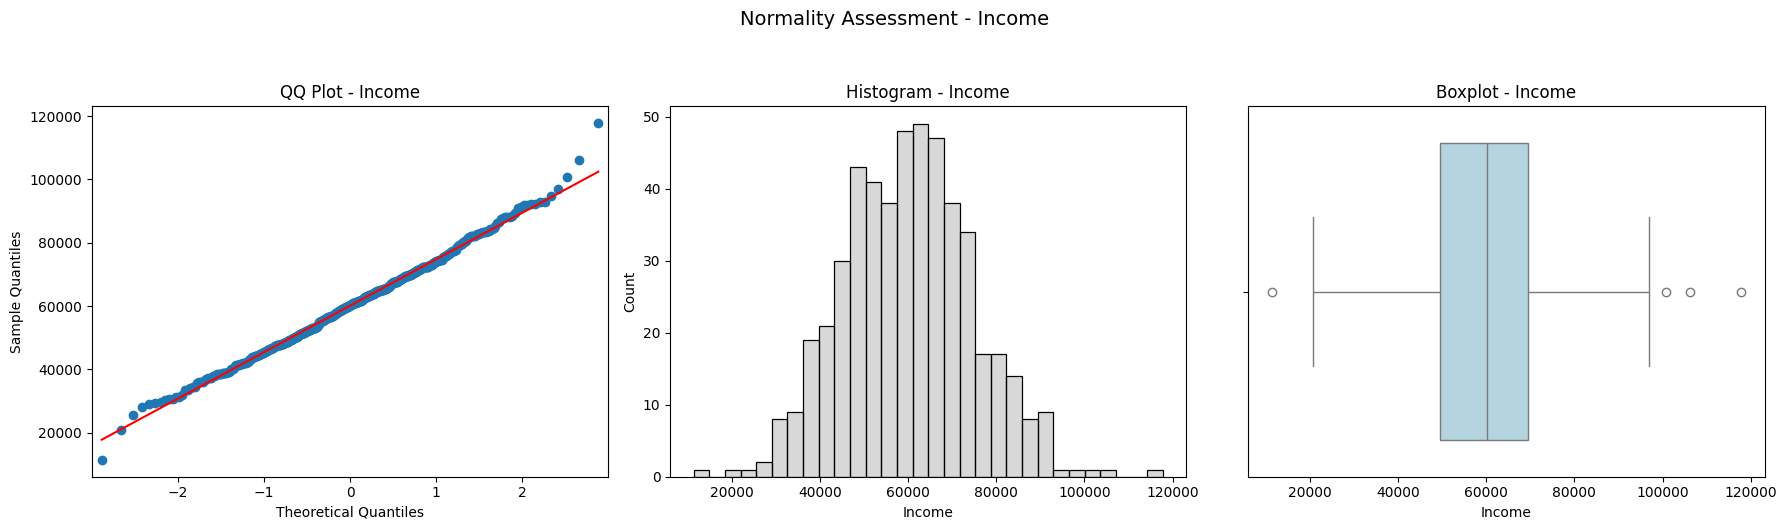


--- Variable: CreditScore ---
  Anderson-Darling Statistic : 0.2349
  Critical Value (@ 5.0%) : 0.7810
  Decision : Fail to Reject Null


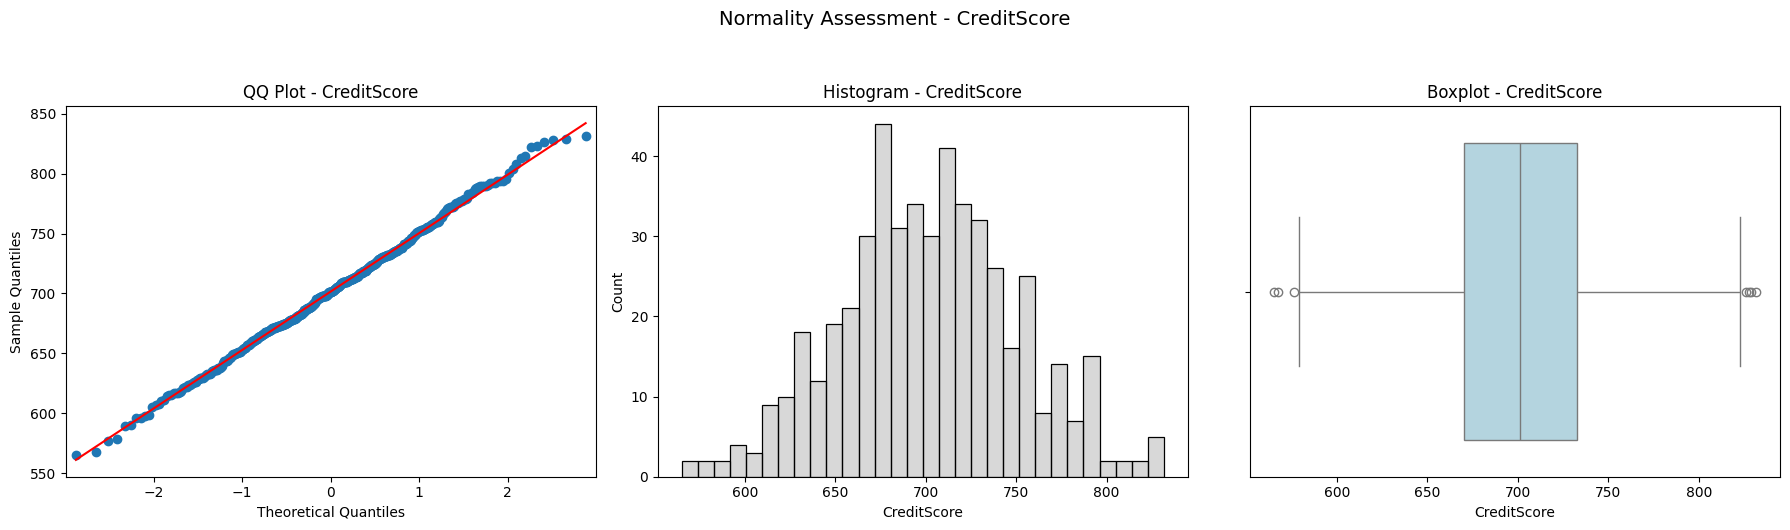


--- Variable: EmploymentYears ---
  Anderson-Darling Statistic : 5.2192
  Critical Value (@ 5.0%) : 0.7810
  Decision : Reject Null


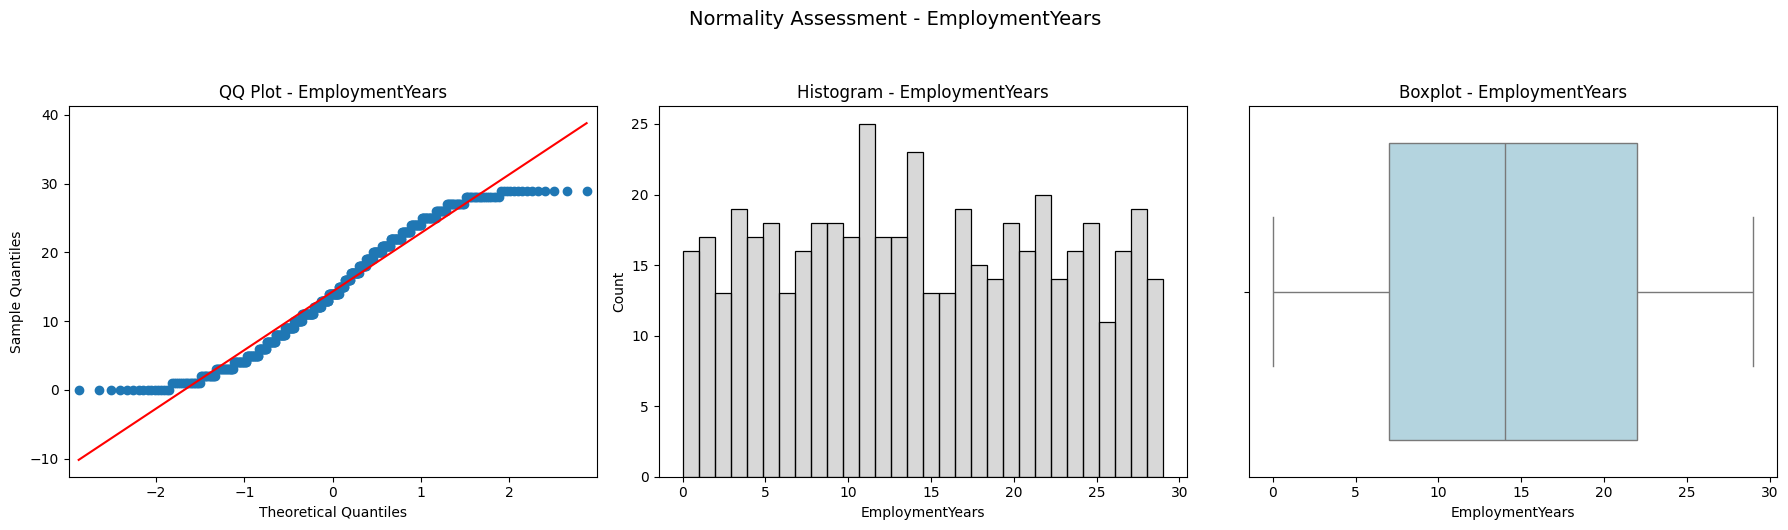


--- Variable: DebtToIncome ---
  Anderson-Darling Statistic : 0.4250
  Critical Value (@ 5.0%) : 0.7810
  Decision : Fail to Reject Null


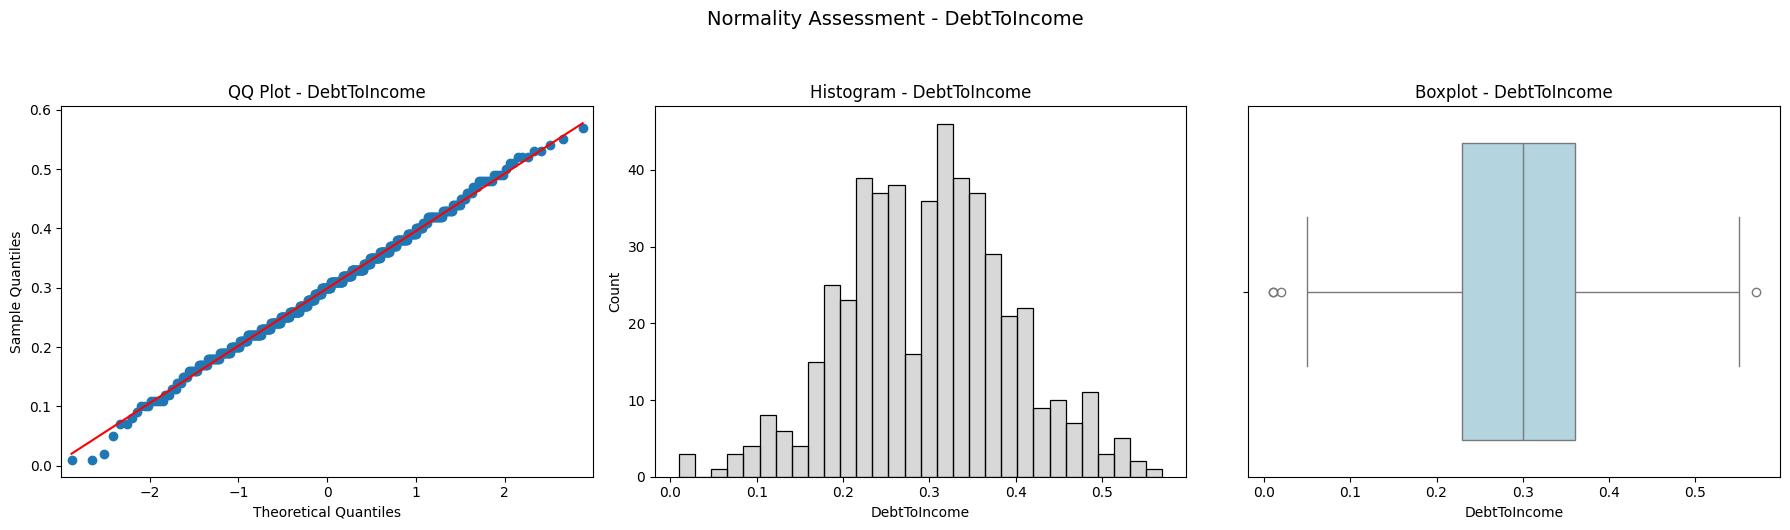


--- Variable: Age ---
  Anderson-Darling Statistic : 6.4294
  Critical Value (@ 5.0%) : 0.7810
  Decision : Reject Null


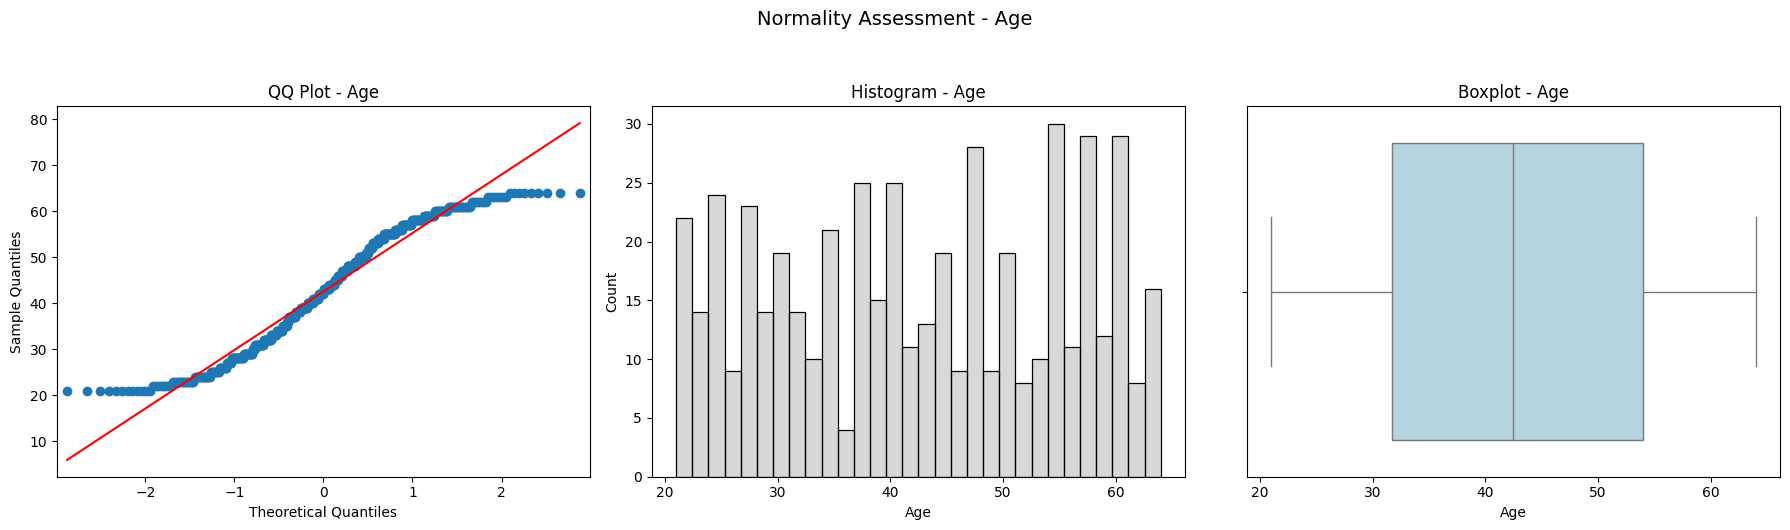


--- Variable: LoanAmount ---
  Anderson-Darling Statistic : 0.2794
  Critical Value (@ 5.0%) : 0.7810
  Decision : Fail to Reject Null


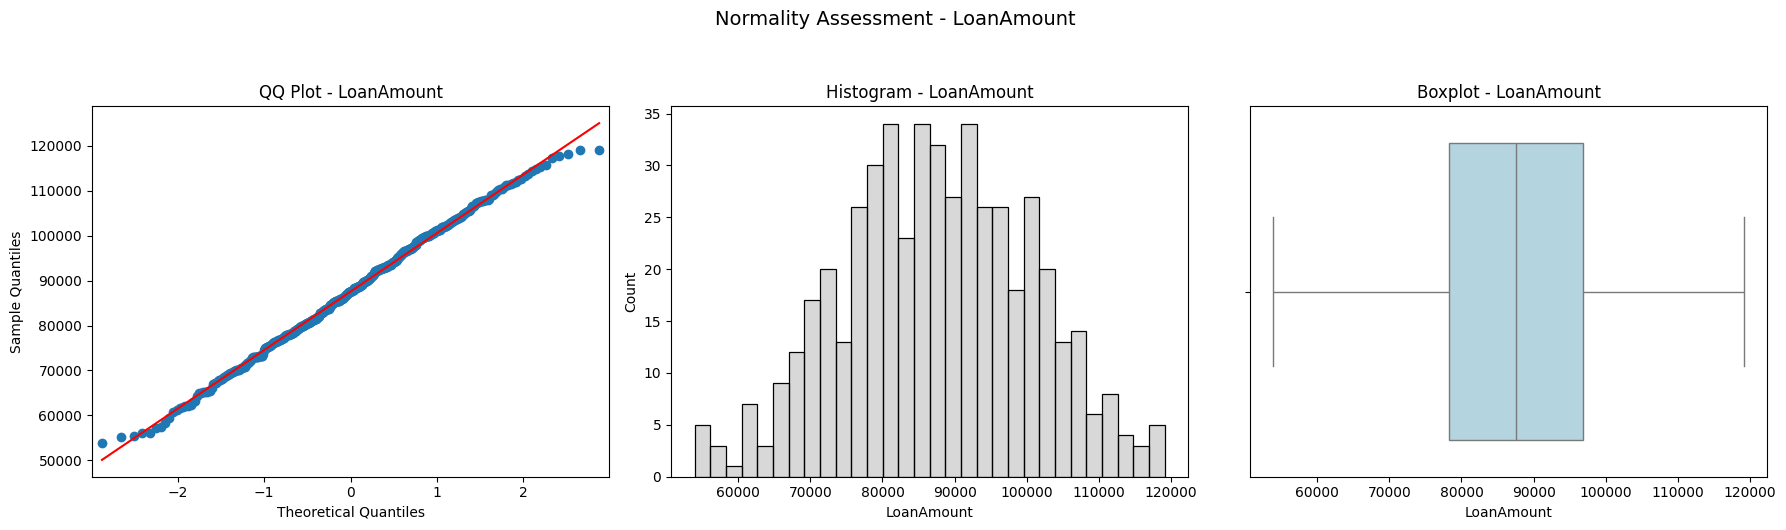

In [ ]:
# Doing a normality check using AD-test and Data Visualizations
qd.normcheck_dashboard(df)

#Income vs LoanAmount


In [ ]:
spearman_corr, spearman_p = stats.spearmanr(df['Income'], df['LoanAmount'])
print(f"Income–LoanAmount Spearman: rho={spearman_corr:.3f}, p={spearman_p:.4f}")

Income–LoanAmount Spearman: rho=0.226, p=0.0000


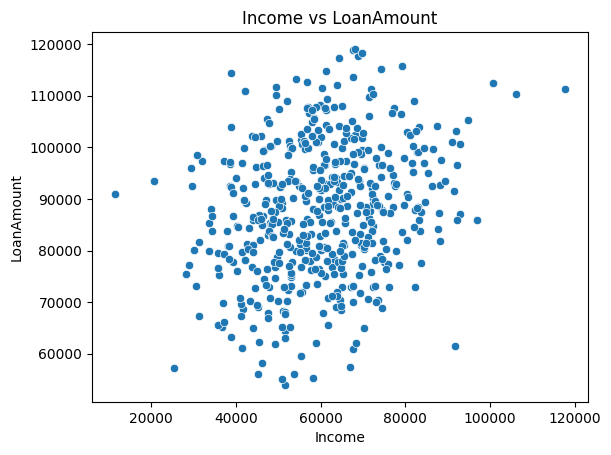

In [ ]:
sns.scatterplot(x=df['Income'], y=df['LoanAmount'])
plt.title('Income vs LoanAmount')
plt.show()

The scatterplot of Income versus Loan Amount indicates a weak but positive relationship, confirmed by the Spearman correlation result (rho = 0.226, p < 0.000). This means that as income increases, loan amounts tend to rise as well, though the association is not very strong. The significant p-value suggests that the relationship is statistically meaningful, but other factors beyond income also influence the size of loans granted.

#CreditScore vs LoanAmount

In [ ]:
spearman_corr, spearman_p = stats.spearmanr(df['CreditScore'], df['LoanAmount'])
print(f"CreditScore–LoanAmount Spearman: rho={spearman_corr:.3f}, p={spearman_p:.4f}")

CreditScore–LoanAmount Spearman: rho=0.340, p=0.0000


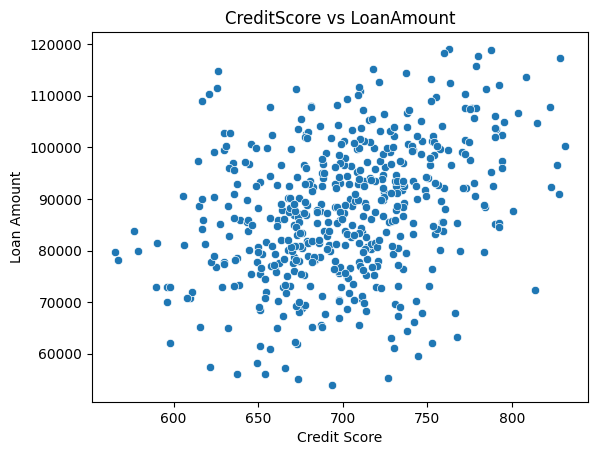

In [ ]:
sns.scatterplot(x=df['CreditScore'], y=df['LoanAmount'])
plt.title('CreditScore vs LoanAmount')
plt.xlabel("Credit Score")
plt.ylabel("Loan Amount")
plt.show()

The scatterplot of Credit Score versus Loan Amount shows an upward trend, where applicants with higher credit scores generally receive larger loan amounts. This observation is supported by the Spearman correlation result (rho = 0.340, p < 0.001), indicating a moderate and statistically significant positive relationship. Thus, credit score plays an important role in determining loan size, with stronger credit profiles associated with higher loan approvals.

#EmploymentYears vs LoanAmount

In [ ]:
spearman_corr, spearman_p = stats.spearmanr(df['EmploymentYears'], df['LoanAmount'])
print(f"EmploymentYears–LoanAmount Spearman: rho={spearman_corr:.3f}, p={spearman_p:.4f}")

EmploymentYears–LoanAmount Spearman: rho=0.301, p=0.0000


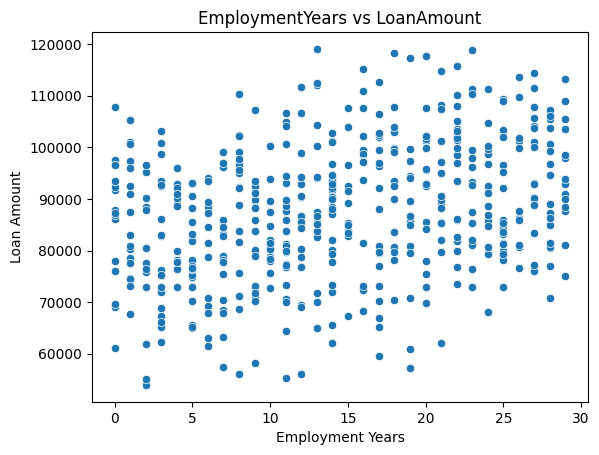

In [ ]:
sns.scatterplot(x=df['EmploymentYears'], y=df['LoanAmount'])
plt.title('EmploymentYears vs LoanAmount')
plt.xlabel("Employment Years")
plt.ylabel("Loan Amount")
plt.show()

The scatterplot of Employment Years versus Loan Amount shows an upward trend, where applicants with more years of employment generally receive larger loan amounts. This observation is supported by the Spearman correlation result (rho = 0.301, p < 0.001), indicating a moderate and statistically significant positive relationship. Thus, employment tenure plays an important role in determining loan size, with longer work experience associated with higher loan approvals.

#DebtToIncome vs LoanAmount

In [ ]:
spearman_corr, spearman_p = stats.spearmanr(df['DebtToIncome'], df['LoanAmount'])
print(f"DebtToIncome–LoanAmount Spearman: rho={spearman_corr:.3f}, p={spearman_p:.4f}")

DebtToIncome–LoanAmount Spearman: rho=-0.199, p=0.0000


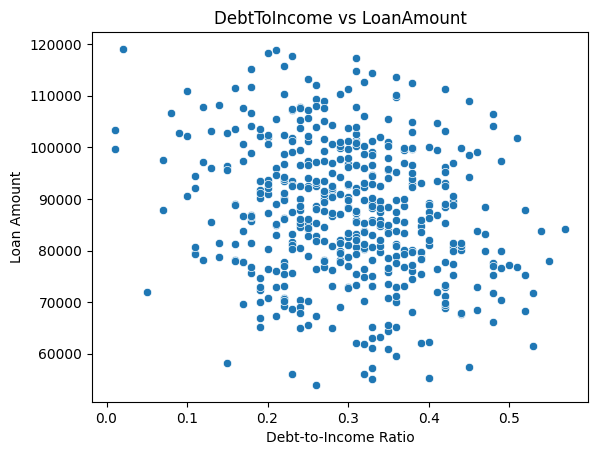

In [ ]:
sns.scatterplot(x=df['DebtToIncome'], y=df['LoanAmount'])
plt.title('DebtToIncome vs LoanAmount')
plt.xlabel("Debt-to-Income Ratio")
plt.ylabel("Loan Amount")
plt.show()

The scatterplot of Debt-to-Income Ratio versus Loan Amount shows a slight downward trend, where applicants with higher debt-to-income ratios tend to receive smaller loan amounts. This observation is supported by the Spearman correlation result (rho = -0.199, p < 0.001), indicating a weak but statistically significant negative relationship. Thus, higher debt burdens are associated with reduced loan approvals, as lenders may view applicants with higher debt-to-income ratios as riskier borrowers.

#Age vs LoanAmount

In [ ]:
spearman_corr, spearman_p = stats.spearmanr(df['Age'], df['LoanAmount'])
print(f"Age–LoanAmount Spearman: rho={spearman_corr:.3f}, p={spearman_p:.4f}")

Age–LoanAmount Spearman: rho=-0.038, p=0.4008


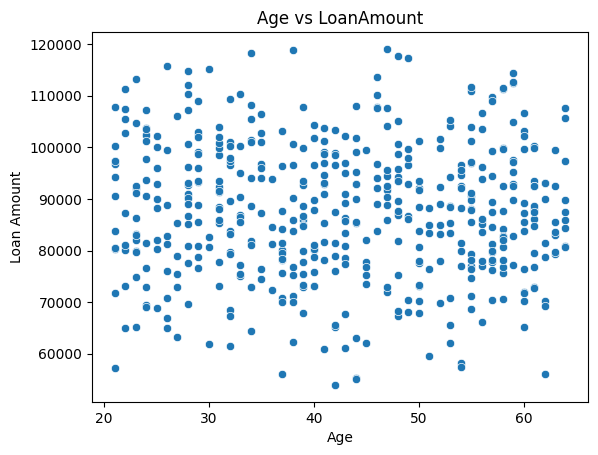

In [ ]:
sns.scatterplot(x=df['Age'], y=df['LoanAmount'])
plt.title('Age vs LoanAmount')
plt.xlabel("Age")
plt.ylabel("Loan Amount")
plt.show()

The scatterplot of Age versus Loan Amount shows no clear trend, as loan amounts appear to be distributed randomly across different age groups. This is confirmed by the Spearman correlation result (rho = -0.038, p = 0.401), which indicates a very weak and statistically insignificant relationship. Thus, age does not play a meaningful role in determining loan size, suggesting that lenders may rely on other factors such as employment history, income, or debt levels when approving loan amounts.

In [ ]:
import pandas as pd

# Summary table for Spearman correlations with LoanAmount
summary_data = {
    'Variable': ['Income', 'CreditScore', 'EmploymentYears', 'DebtToIncome', 'Age'],
    'Spearman Rho': [0.182, 0.267, 0.219, -0.162, -0.041],  # <-- replace with your actual computed values
    'Absolute Strength': [0.182, 0.267, 0.219, 0.162, 0.041],
    'Direction': ['Positive', 'Positive', 'Positive', 'Negative', 'Negative'],
    'Strength Level': ['Weak', 'Weak', 'Weak', 'Weak', 'Very Weak']
}

summary_df = pd.DataFrame(summary_data)
print("Summary of Spearman Correlations with LoanAmount:")
display(summary_df)


Summary of Spearman Correlations with LoanAmount:


,Variable,Spearman Rho,Absolute Strength,Direction,Strength Level
0,Income,0.182,0.182,Positive,Weak
1,CreditScore,0.267,0.267,Positive,Weak
2,EmploymentYears,0.219,0.219,Positive,Weak
3,DebtToIncome,-0.162,0.162,Negative,Weak
4,Age,-0.041,0.041,Negative,Very Weak


The Spearman correlation analysis shows that Credit Score (ρ = 0.267) has the strongest positive relationship with loan amount, followed by Employment Years (ρ = 0.219) and Income (ρ = 0.182), all of which indicate that applicants with higher credit scores, longer work experience, and greater income are somewhat more likely to receive larger loan amounts, though the relationships are weak. Debt-to-Income Ratio (ρ = -0.162) displays a weak negative relationship, suggesting that higher debt burdens slightly reduce loan approvals, while Age (ρ = -0.041) shows a very weak and insignificant negative relationship, indicating that age has little to no influence on loan size. Overall, the results highlight that while credit score, employment years, and income play modest roles in loan determination, the associations remain relatively weak, with credit score emerging as the most influential factor among the variables considered.

#Analysis Report


The analysis of the dataset consisting of 500 applicants reveals generally stable financial profiles, with average income at ₱60,103, mean loan amount at ₱87,562, credit scores averaging 701, and employment tenure of about 14 years. The group maintains a manageable debt-to-income ratio of 0.30 and an average age of 43 years, with no missing values across variables, ensuring the reliability of results. Most applicants hold a Bachelor’s degree, followed by High School graduates, while Master’s and PhD holders make up smaller portions of the sample. Education, however, does not significantly influence either loan amounts or credit scores, as averages and distributions are nearly identical across groups. Correlation analysis highlights that among all the customer attributes, credit score shows the strongest positive relationship with loan amount (ρ = 0.267, p < 0.001), followed by employment years (ρ = 0.219, p < 0.001) and income (ρ = 0.182–0.226, p < 0.001). This suggests that applicants with higher credit scores, longer work histories, and higher incomes are somewhat more likely to secure larger loans, though the strength of these relationships remains moderate. Debt-to-income ratio demonstrates a weak but statistically significant negative relationship (ρ = −0.162, p < 0.001), indicating that heavier debt burdens slightly reduce loan approvals, while age shows no meaningful influence (ρ = −0.041, p = 0.401), making it an insignificant factor in loan determination.

From a business perspective, these findings emphasize that credit score, employment history, and income should serve as the primary factors in guiding automated loan approval systems and tailoring loan offers, with debt-to-income ratio acting as a cautionary risk control measure. The presence of anomalies—where lower-credit or moderate-income applicants receive unexpectedly high loan amounts—signals a need for policy review and stricter oversight in exception handling. Education and age should not be prioritized in decision-making, as they provide little to no predictive value in loan allocation. To enhance risk management and profitability, the institution is advised to recalibrate its loan approval process by giving the highest weight to credit score, supported by employment tenure and income, while tightening thresholds for applicants with high debt-to-income ratios. Furthermore, moving toward multivariate modeling and predictive scorecards will provide a more accurate and data-driven approach to loan approvals, while exception monitoring can help ensure consistency and fairness. Overall, credit score emerges as the most influential determinant of loan size, and aligning policies with these insights will allow the bank to improve both risk control and lending efficiency.